In [1]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_ID = "turkiye-border-wellbeing-2026"

ee.Authenticate()
ee.Initialize(project=PROJECT_ID)

print("Earth Engine ready.")

Mounted at /content/drive
Earth Engine ready.


In [3]:
ROOT = Path("/content/drive/MyDrive/turkiye-border-wellbeing")

INTERIM = ROOT / "data/interim"
RAW_VIIRS = ROOT / "data/raw/viirs"
PROCESSED = ROOT / "data/processed"
FIGURES = ROOT / "figures/appendix"

RAW_VIIRS.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

In [4]:
grid = gpd.read_file(
    INTERIM / "grid_1km_master.gpkg"
)

print("Grid cells:", len(grid))
print("CRS:", grid.crs)

Grid cells: 19001
CRS: EPSG:32635


In [5]:
grid_wgs84 = grid[
    ["grid_id", "geometry"]
].to_crs("EPSG:4326")

study_area_geom = grid_wgs84.union_all()

study_area_ee = geemap.geopandas_to_ee(
    gpd.GeoDataFrame(
        geometry=[study_area_geom],
        crs="EPSG:4326"
    )
).geometry()

In [6]:
VIIRS_ID = "NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG"

viirs = (
    ee.ImageCollection(VIIRS_ID)
    .filterDate("2014-01-01", "2026-01-01")
    .filterBounds(study_area_ee)
)

print("VIIRS monthly images:", viirs.size().getInfo())

VIIRS monthly images: 144


In [7]:
for year in range(2014, 2026):

    n = (
        viirs
        .filterDate(
            f"{year}-01-01",
            f"{year + 1}-01-01"
        )
        .size()
        .getInfo()
    )

    print(year, n)

2014 12
2015 12
2016 12
2017 12
2018 12
2019 12
2020 12
2021 12
2022 12
2023 12
2024 12
2025 12


In [8]:
def mask_viirs(image):

    radiance = image.select("avg_rad")
    coverage = image.select("cf_cvg")

    valid = coverage.gt(0)

    return (
        radiance
        .updateMask(valid)
        .copyProperties(
            image,
            ["system:time_start"]
        )
    )

In [10]:
def clean_viirs(image):

    radiance = image.select("avg_rad")
    coverage = image.select("cf_cvg")

    valid = coverage.gt(0).And(radiance.gte(0))

    return (
        radiance
        .updateMask(valid)
        .copyProperties(
            image,
            ["system:time_start"]
        )
    )

In [11]:
viirs_clean = viirs.map(clean_viirs)

print("Clean VIIRS collection created.")

Clean VIIRS collection created.


In [12]:
def annual_viirs(year):

    year = int(year)

    annual = (
        viirs_clean
        .filterDate(
            f"{year}-01-01",
            f"{year + 1}-01-01"
        )
        .mean()
        .rename("viirs_avg_rad")
    )

    return annual.set("year", year)

In [13]:
viirs_2024 = annual_viirs(2024)

print(viirs_2024.bandNames().getInfo())

['viirs_avg_rad']


In [15]:
grid_ee = geemap.geopandas_to_ee(grid_wgs84)

In [16]:
annual_images = []

for year in range(2014, 2026):
    img = (
        annual_viirs(year)
        .rename(f"viirs_{year}")
    )
    annual_images.append(img)

viirs_stack = ee.Image.cat(annual_images)

print(viirs_stack.bandNames().getInfo())

['viirs_2014', 'viirs_2015', 'viirs_2016', 'viirs_2017', 'viirs_2018', 'viirs_2019', 'viirs_2020', 'viirs_2021', 'viirs_2022', 'viirs_2023', 'viirs_2024', 'viirs_2025']


In [17]:
BATCH_SIZE = 500

n = len(grid_wgs84)

print("Total grids:", n)
print("Number of batches:",
      int(np.ceil(n / BATCH_SIZE)))

Total grids: 19001
Number of batches: 39


In [19]:
BATCH_SIZE = 500

test_batch = grid_wgs84.iloc[:BATCH_SIZE].copy()

print("Test batch rows:", len(test_batch))

Test batch rows: 500


In [20]:
test_ee = geemap.geopandas_to_ee(
    test_batch[["grid_id", "geometry"]]
)

print("Test EE features:", test_ee.size().getInfo())

Test EE features: 500


In [21]:
test_stats = viirs_stack.reduceRegions(
    collection=test_ee,
    reducer=ee.Reducer.mean(),
    scale=500,
    tileScale=4
)

test_df = geemap.ee_to_df(test_stats)

print("Shape:", test_df.shape)
print(test_df.columns.tolist())
test_df.head()

Shape: (500, 13)
['grid_id', 'viirs_2014', 'viirs_2015', 'viirs_2016', 'viirs_2017', 'viirs_2018', 'viirs_2019', 'viirs_2020', 'viirs_2021', 'viirs_2022', 'viirs_2023', 'viirs_2024', 'viirs_2025']


,grid_id,viirs_2014,viirs_2015,viirs_2016,viirs_2017,viirs_2018,viirs_2019,viirs_2020,viirs_2021,viirs_2022,viirs_2023,viirs_2024,viirs_2025
0,G000001,0.212442,0.162887,0.160412,0.336994,0.305717,0.328541,0.369384,0.434329,0.429497,0.454782,0.458682,0.411175
1,G000002,0.189471,0.150939,0.148293,0.324718,0.289214,0.302087,0.348392,0.394767,0.403744,0.436797,0.438521,0.395067
2,G000003,0.255223,0.194756,0.204730,0.371908,0.353567,0.363959,0.426228,0.512619,0.473491,0.541001,0.515144,0.483913
3,G000004,0.283943,0.217329,0.215515,0.394878,0.373580,0.368817,0.423810,0.504751,0.467685,0.540339,0.516220,0.485975
4,G000005,0.253181,0.202441,0.195506,0.374148,0.349239,0.344988,0.395805,0.469534,0.453366,0.508702,0.474674,0.451650


In [22]:
BATCH_SIZE = 500

all_batches = []

for start in range(0, len(grid_wgs84), BATCH_SIZE):

    end = min(start + BATCH_SIZE, len(grid_wgs84))

    print(
        f"Processing grids {start:,}–{end:,} "
        f"of {len(grid_wgs84):,}"
    )

    batch_gdf = (
        grid_wgs84
        .iloc[start:end]
        [["grid_id", "geometry"]]
        .copy()
    )

    batch_ee = geemap.geopandas_to_ee(
        batch_gdf
    )

    batch_stats = viirs_stack.reduceRegions(
        collection=batch_ee,
        reducer=ee.Reducer.mean(),
        scale=500,
        tileScale=4
    )

    batch_df = geemap.ee_to_df(
        batch_stats
    )

    all_batches.append(batch_df)

print("All batches completed.")

Processing grids 0–500 of 19,001
Processing grids 500–1,000 of 19,001
Processing grids 1,000–1,500 of 19,001
Processing grids 1,500–2,000 of 19,001
Processing grids 2,000–2,500 of 19,001
Processing grids 2,500–3,000 of 19,001
Processing grids 3,000–3,500 of 19,001
Processing grids 3,500–4,000 of 19,001
Processing grids 4,000–4,500 of 19,001
Processing grids 4,500–5,000 of 19,001
Processing grids 5,000–5,500 of 19,001
Processing grids 5,500–6,000 of 19,001
Processing grids 6,000–6,500 of 19,001
Processing grids 6,500–7,000 of 19,001
Processing grids 7,000–7,500 of 19,001
Processing grids 7,500–8,000 of 19,001
Processing grids 8,000–8,500 of 19,001
Processing grids 8,500–9,000 of 19,001
Processing grids 9,000–9,500 of 19,001
Processing grids 9,500–10,000 of 19,001
Processing grids 10,000–10,500 of 19,001
Processing grids 10,500–11,000 of 19,001
Processing grids 11,000–11,500 of 19,001
Processing grids 11,500–12,000 of 19,001
Processing grids 12,000–12,500 of 19,001
Processing grids 12,50

In [23]:
viirs_wide = pd.concat(
    all_batches,
    ignore_index=True
)

print("Rows:", len(viirs_wide))
print("Columns:", len(viirs_wide.columns))

viirs_wide.head()

Rows: 19001
Columns: 13


,grid_id,viirs_2014,viirs_2015,viirs_2016,viirs_2017,viirs_2018,viirs_2019,viirs_2020,viirs_2021,viirs_2022,viirs_2023,viirs_2024,viirs_2025
0,G000001,0.212442,0.162887,0.160412,0.336994,0.305717,0.328541,0.369384,0.434329,0.429497,0.454782,0.458682,0.411175
1,G000002,0.189471,0.150939,0.148293,0.324718,0.289214,0.302087,0.348392,0.394767,0.403744,0.436797,0.438521,0.395067
2,G000003,0.255223,0.194756,0.204730,0.371908,0.353567,0.363959,0.426228,0.512619,0.473491,0.541001,0.515144,0.483913
3,G000004,0.283943,0.217329,0.215515,0.394878,0.373580,0.368817,0.423810,0.504751,0.467685,0.540339,0.516220,0.485975
4,G000005,0.253181,0.202441,0.195506,0.374148,0.349239,0.344988,0.395805,0.469534,0.453366,0.508702,0.474674,0.451650


In [24]:
print(
    "Unique grid IDs:",
    viirs_wide["grid_id"].nunique()
)

print(
    "Duplicated grid IDs:",
    viirs_wide["grid_id"].duplicated().sum()
)

Unique grid IDs: 19001
Duplicated grid IDs: 0


In [25]:
viirs_cols = [
    f"viirs_{year}"
    for year in range(2014, 2026)
]

viirs_panel = (
    viirs_wide[
        ["grid_id"] + viirs_cols
    ]
    .melt(
        id_vars="grid_id",
        var_name="year",
        value_name="viirs_avg_rad"
    )
)

viirs_panel["year"] = (
    viirs_panel["year"]
    .str.replace("viirs_", "", regex=False)
    .astype(int)
)

viirs_panel = (
    viirs_panel
    .sort_values(["grid_id", "year"])
    .reset_index(drop=True)
)

print("Panel observations:", len(viirs_panel))
print(viirs_panel.head(15))

Panel observations: 228012
    grid_id  year  viirs_avg_rad
0   G000001  2014       0.212442
1   G000001  2015       0.162887
2   G000001  2016       0.160412
3   G000001  2017       0.336994
4   G000001  2018       0.305717
5   G000001  2019       0.328541
6   G000001  2020       0.369384
7   G000001  2021       0.434329
8   G000001  2022       0.429497
9   G000001  2023       0.454782
10  G000001  2024       0.458682
11  G000001  2025       0.411175
12  G000002  2014       0.189471
13  G000002  2015       0.150939
14  G000002  2016       0.148293


In [26]:
print(
    "Missing VIIRS observations:",
    viirs_panel["viirs_avg_rad"]
    .isna()
    .sum()
)

print()

print(
    viirs_panel["viirs_avg_rad"]
    .describe()
)

Missing VIIRS observations: 0

count    228012.000000
mean          1.462377
std           4.798880
min           0.068921
25%           0.365602
50%           0.531227
75%           0.920682
max         400.840164
Name: viirs_avg_rad, dtype: float64


In [27]:
year_qc = (
    viirs_panel
    .groupby("year")["viirs_avg_rad"]
    .agg(
        count="count",
        missing=lambda x: x.isna().sum(),
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

print(year_qc)

      count  missing      mean    median       std       min         max
year                                                                    
2014  19001        0  0.946344  0.280835  3.095773  0.120631   65.590583
2015  19001        0  0.956238  0.235533  3.383087  0.090839   73.311895
2016  19001        0  1.002801  0.240439  3.572249  0.068921   80.682991
2017  19001        0  1.313033  0.456410  4.132269  0.226979  140.190555
2018  19001        0  1.359548  0.423545  5.935582  0.188095  400.840164
2019  19001        0  1.502771  0.484397  5.452051  0.220264  269.796295
2020  19001        0  1.547968  0.540814  5.302710  0.284594  256.623339
2021  19001        0  1.672307  0.606271  5.284668  0.331189  209.832932
2022  19001        0  1.714234  0.603914  4.994436  0.325406   85.947408
2023  19001        0  1.782835  0.670447  4.985502  0.348597   92.065609
2024  19001        0  1.881977  0.714389  5.133174  0.378562  103.398291
2025  19001        0  1.868465  0.670681  5.198104 

In [28]:
viirs_wide_path = (
    INTERIM /
    "viirs_grid_annual_wide_2014_2025.csv"
)

viirs_wide.to_csv(
    viirs_wide_path,
    index=False
)

print("Saved:", viirs_wide_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/viirs_grid_annual_wide_2014_2025.csv


In [29]:
viirs_panel_path = (
    PROCESSED /
    "viirs_grid_year_2014_2025.csv"
)

viirs_panel.to_csv(
    viirs_panel_path,
    index=False
)

print("Saved:", viirs_panel_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/processed/viirs_grid_year_2014_2025.csv


In [30]:
top20 = (
    viirs_panel
    .sort_values(
        "viirs_avg_rad",
        ascending=False
    )
    .head(20)
)

print(top20)

        grid_id  year  viirs_avg_rad
187372  G015615  2018     400.840164
187360  G015614  2018     356.774232
187373  G015615  2019     269.796295
187361  G015614  2019     260.235912
187362  G015614  2020     256.623339
187374  G015615  2020     242.558639
187375  G015615  2021     209.832932
187363  G015614  2021     186.683442
188668  G015723  2018     179.270817
188658  G015722  2020     178.218644
188669  G015723  2019     156.328125
188657  G015722  2019     154.798929
188656  G015722  2018     154.604339
188671  G015723  2021     149.993446
187371  G015615  2017     140.190555
188670  G015723  2020     140.167586
188659  G015722  2021     139.778510
218962  G018247  2024     103.398291
218963  G018247  2025     101.955426
218961  G018247  2023      92.065609


In [31]:
grid_info = grid[
    [
        "grid_id",
        "province",
        "district",
        "longitude",
        "latitude"
    ]
].copy()

top20_loc = top20.merge(
    grid_info,
    on="grid_id",
    how="left"
)

print(
    top20_loc[
        [
            "grid_id",
            "year",
            "viirs_avg_rad",
            "province",
            "district",
            "longitude",
            "latitude"
        ]
    ]
)

    grid_id  year  viirs_avg_rad  province   district  longitude   latitude
0   G015615  2018     400.840164  Tekirdag      Corlu  27.709946  41.229705
1   G015614  2018     356.774232  Tekirdag      Corlu  27.709849  41.220698
2   G015615  2019     269.796295  Tekirdag      Corlu  27.709946  41.229705
3   G015614  2019     260.235912  Tekirdag      Corlu  27.709849  41.220698
4   G015614  2020     256.623339  Tekirdag      Corlu  27.709849  41.220698
5   G015615  2020     242.558639  Tekirdag      Corlu  27.709946  41.229705
6   G015615  2021     209.832932  Tekirdag      Corlu  27.709946  41.229705
7   G015614  2021     186.683442  Tekirdag      Corlu  27.709849  41.220698
8   G015723  2018     179.270817  Tekirdag      Corlu  27.721877  41.229631
9   G015722  2020     178.218644  Tekirdag      Corlu  27.721778  41.220624
10  G015723  2019     156.328125  Tekirdag      Corlu  27.721877  41.229631
11  G015722  2019     154.798929  Tekirdag      Corlu  27.721778  41.220624
12  G015722 

In [32]:
max_grid = (
    viirs_panel
    .loc[
        viirs_panel["viirs_avg_rad"].idxmax(),
        "grid_id"
    ]
)

print("Maximum grid:", max_grid)

print(
    viirs_panel[
        viirs_panel["grid_id"] == max_grid
    ]
)

Maximum grid: G015615
        grid_id  year  viirs_avg_rad
187368  G015615  2014      19.934280
187369  G015615  2015      20.536320
187370  G015615  2016      19.858950
187371  G015615  2017     140.190555
187372  G015615  2018     400.840164
187373  G015615  2019     269.796295
187374  G015615  2020     242.558639
187375  G015615  2021     209.832932
187376  G015615  2022      36.071053
187377  G015615  2023      12.398327
187378  G015615  2024      11.862219
187379  G015615  2025      12.462908


In [33]:
max_grid_info = grid[
    grid["grid_id"] == "G015615"
][
    [
        "grid_id",
        "province",
        "district",
        "longitude",
        "latitude"
    ]
]

print(max_grid_info)

       grid_id  province district  longitude   latitude
15614  G015615  Tekirdag    Corlu  27.709946  41.229705


In [34]:
target = grid[
    grid["grid_id"] == "G015615"
].copy()

target_geom = target.geometry.iloc[0]

neighbors = grid[
    grid.geometry.distance(target_geom) <= 3000
][
    ["grid_id", "province", "district"]
].copy()

print("Nearby grids:", len(neighbors))

Nearby grids: 61


In [35]:
neighbor_series = (
    viirs_panel[
        viirs_panel["grid_id"].isin(
            neighbors["grid_id"]
        )
    ]
    .groupby("year")["viirs_avg_rad"]
    .agg(["median", "mean", "max"])
)

print(neighbor_series)

        median       mean         max
year                                 
2014  1.610860   5.123757   28.738010
2015  1.564433   5.114143   29.574936
2016  1.735986   5.346309   29.768491
2017  2.429258  10.467440  140.190555
2018  4.417741  25.103368  400.840164
2019  3.510515  20.416299  269.796295
2020  3.436030  19.989329  256.623339
2021  3.392777  18.054329  209.832932
2022  2.758758   8.089439   36.071053
2023  2.751958   7.013512   36.070233
2024  2.909032   7.228124   38.325792
2025  2.921521   7.437916   39.670589


In [36]:
target = grid[
    grid["grid_id"] == "G015615"
].copy()

target_geom = target.geometry.iloc[0]

neighbors = grid[
    grid.geometry.distance(target_geom) <= 3000
][
    ["grid_id", "province", "district"]
].copy()

print("Nearby grids:", len(neighbors))

Nearby grids: 61


In [37]:
wide_check = viirs_panel.pivot(
    index="grid_id",
    columns="year",
    values="viirs_avg_rad"
)

wide_check["change_2016_2017"] = (
    wide_check[2017] - wide_check[2016]
)

print(
    wide_check["change_2016_2017"].describe()
)

count    19001.000000
mean         0.310232
std          1.182789
min         -4.573957
25%          0.186740
50%          0.211315
75%          0.255026
max        120.331605
Name: change_2016_2017, dtype: float64


In [38]:
print(
    wide_check["change_2016_2017"]
    .sort_values(ascending=False)
    .head(20)
)

grid_id
G015615    120.331605
G015614     59.354371
G015723     39.594313
G015722     32.951217
G000906     20.298527
G006210     20.191263
G002535     14.699958
G006349     12.102362
G010501     12.006178
G002430     11.850938
G016142     11.455757
G002643     11.409809
G002431     10.356486
G012030     10.313676
G012304     10.276158
G012163      9.605598
G002641      9.567856
G002640      9.528434
G002642      9.192301
G012162      9.080905
Name: change_2016_2017, dtype: float64


In [39]:
wide_log = np.log1p(
    viirs_panel.pivot(
        index="grid_id",
        columns="year",
        values="viirs_avg_rad"
    )
)

wide_log["dlog_2016_2017"] = (
    wide_log[2017] - wide_log[2016]
)

print(
    wide_log["dlog_2016_2017"].describe()
)

count    19001.000000
mean         0.152470
std          0.059100
min         -0.607298
25%          0.140096
50%          0.154743
75%          0.169092
max          1.998691
Name: dlog_2016_2017, dtype: float64


In [40]:
log_panel = viirs_panel.copy()

log_panel["ln_viirs"] = np.log1p(
    log_panel["viirs_avg_rad"]
)

log_wide = log_panel.pivot(
    index="grid_id",
    columns="year",
    values="ln_viirs"
)

yearly_changes = {}

for year in range(2015, 2026):
    diff = log_wide[year] - log_wide[year - 1]

    yearly_changes[year] = {
        "median_dlog": diff.median(),
        "mean_dlog": diff.mean(),
        "p25": diff.quantile(0.25),
        "p75": diff.quantile(0.75)
    }

yearly_changes_df = pd.DataFrame(yearly_changes).T

print(yearly_changes_df)

      median_dlog  mean_dlog       p25       p75
2015    -0.028475  -0.020719 -0.042282 -0.012055
2016     0.000677   0.006935 -0.015107  0.017630
2017     0.154743   0.152470  0.140096  0.169092
2018    -0.023764  -0.016535 -0.036111 -0.009318
2019     0.036769   0.051354  0.023294  0.058911
2020     0.036984   0.034003  0.021462  0.050643
2021     0.040648   0.043082  0.027617  0.054273
2022    -0.003419   0.004950 -0.015465  0.012472
2023     0.034394   0.033615  0.018110  0.048157
2024     0.019681   0.029688  0.005604  0.039841
2025    -0.018663  -0.017076 -0.035627 -0.001091


In [41]:
yearly_changes_path = (
    INTERIM /
    "viirs_year_to_year_log_change_qc.csv"
)

yearly_changes_df.to_csv(
    yearly_changes_path,
    index_label="year"
)

print("Saved:", yearly_changes_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/viirs_year_to_year_log_change_qc.csv


In [42]:
annual_log_qc = (
    log_panel
    .groupby("year")["ln_viirs"]
    .agg(
        mean="mean",
        median="median"
    )
    .reset_index()
)

print(annual_log_qc)

    year      mean    median
0   2014  0.428965  0.247512
1   2015  0.408246  0.211502
2   2016  0.415181  0.215466
3   2017  0.567651  0.375975
4   2018  0.551116  0.353150
5   2019  0.602470  0.395009
6   2020  0.636473  0.432311
7   2021  0.679555  0.473915
8   2022  0.684505  0.472447
9   2023  0.718121  0.513091
10  2024  0.747808  0.539057
11  2025  0.730733  0.513231


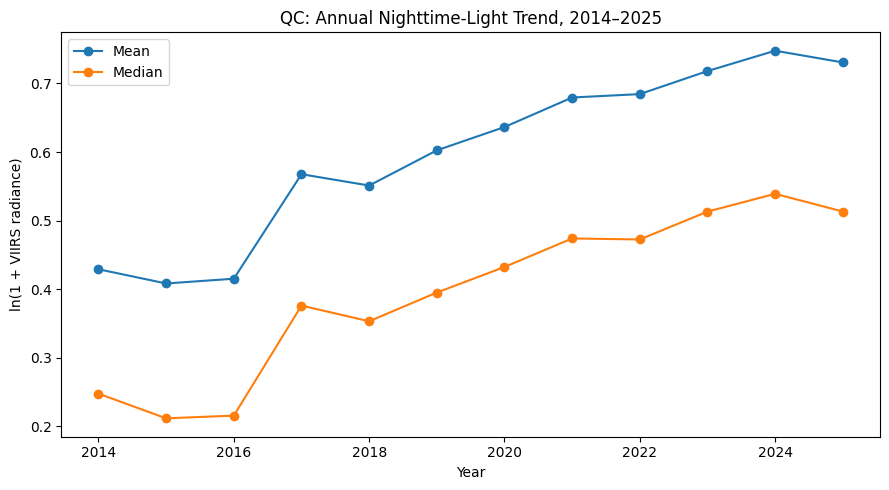

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_viirs_log_annual_trend.png


In [43]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    annual_log_qc["year"],
    annual_log_qc["mean"],
    marker="o",
    label="Mean"
)

ax.plot(
    annual_log_qc["year"],
    annual_log_qc["median"],
    marker="o",
    label="Median"
)

ax.set_xlabel("Year")
ax.set_ylabel("ln(1 + VIIRS radiance)")
ax.set_title(
    "QC: Annual Nighttime-Light Trend, 2014–2025"
)

ax.legend()

plt.tight_layout()

out = (
    FIGURES /
    "qc_viirs_log_annual_trend.png"
)

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out)

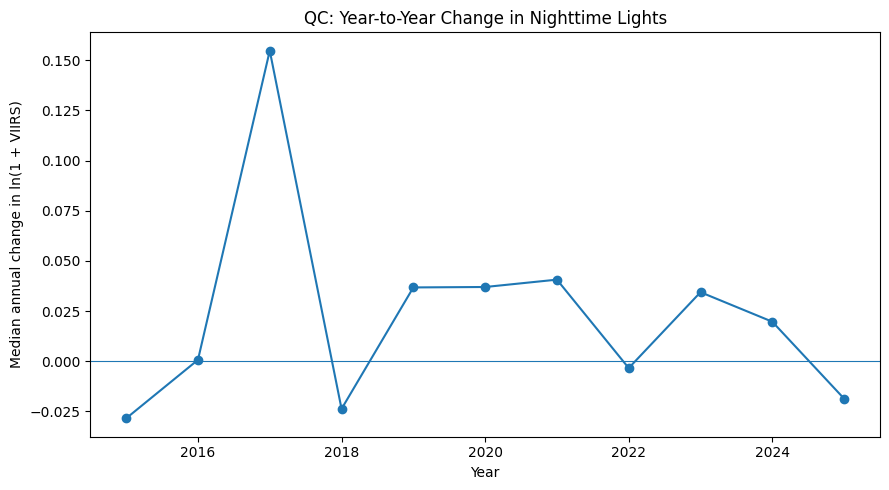

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/figures/appendix/qc_viirs_yearly_log_change.png


In [44]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    yearly_changes_df.index,
    yearly_changes_df["median_dlog"],
    marker="o"
)

ax.axhline(
    0,
    linewidth=0.8
)

ax.set_xlabel("Year")
ax.set_ylabel("Median annual change in ln(1 + VIIRS)")
ax.set_title(
    "QC: Year-to-Year Change in Nighttime Lights"
)

plt.tight_layout()

out = (
    FIGURES /
    "qc_viirs_yearly_log_change.png"
)

plt.savefig(
    out,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", out)

In [45]:
viirs_panel["ln_viirs"] = np.log1p(
    viirs_panel["viirs_avg_rad"]
)

viirs_panel.to_csv(
    PROCESSED /
    "viirs_grid_year_2014_2025.csv",
    index=False
)

In [46]:
year_qc = (
    viirs_panel
    .groupby("year")["viirs_avg_rad"]
    .agg(
        count="count",
        missing=lambda x: x.isna().sum(),
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

year_qc_path = (
    INTERIM /
    "viirs_annual_qc_2014_2025.csv"
)

year_qc.to_csv(
    year_qc_path,
    index_label="year"
)

print("Saved:", year_qc_path)

Saved: /content/drive/MyDrive/turkiye-border-wellbeing/data/interim/viirs_annual_qc_2014_2025.csv
